# Eco-Adaptive Home Storage (DQN)

Notebook pédagogique pour entraîner un agent de **Reinforcement Learning (DQN)** sur un problème de gestion d'énergie résidentielle multi-objectif.

## Objectifs
- Minimiser le coût de l'électricité
- Réduire les émissions de CO2
- Limiter l'usure batterie (changements d'action trop fréquents)

## Modèle
- État: $(h, SoC, P_{net}, C_{grid}, I_{co2})$
- Actions: `0=Charge`, `1=Décharge`, `2=Idle`
- Récompense: $R_t = -(\alpha Cost_t + \eta Emissions_t + \gamma |a_t-a_{t-1}|)$

## Cellule 1 - Imports et réglages globaux
Exécuter cette cellule en premier.

In [1]:
import random
from collections import deque
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Cellule 2 - Environnement Gymnasium (`SmartGridEnv`)
Cette classe simule une journée de 24h en pas de 30 min (48 étapes), avec profils synthétiques réalistes pour la charge nette, le prix et le carbone.

In [2]:
class SmartGridEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        alpha: float = 1.0,
        beta: float = 0.6,
        gamma: float = 0.05,
        battery_capacity_kwh: float = 10.0,
        max_power_kw: float = 3.0,
        eta_charge: float = 0.95,
        eta_discharge: float = 0.95,
        seed: int = 42,
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        self.steps_per_episode = 48
        self.dt_hours = 0.5

        self.battery_capacity_kwh = battery_capacity_kwh
        self.max_power_kw = max_power_kw
        self.eta_charge = eta_charge
        self.eta_discharge = eta_discharge

        self.rng = np.random.default_rng(seed)

        self.action_space = gym.spaces.Discrete(3)
        self.observation_space = gym.spaces.Box(
            low=np.array([0.0, 0.0, -10.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([23.5, 1.0, 10.0, 1.0, 1200.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.current_step = 0
        self.soc = 0.5
        self.prev_action = 2

        self.hour_profile = None
        self.p_net_profile = None
        self.price_profile = None
        self.carbon_profile = None

    def _generate_synthetic_profiles(self):
        t = np.arange(self.steps_per_episode)
        hours = t * self.dt_hours

        day_shift = self.rng.uniform(-1.0, 1.0)

        solar_shape = np.sin((hours - 6.0 + day_shift) * np.pi / 12.0)
        solar_kw = np.clip(solar_shape, 0.0, None)
        solar_kw *= self.rng.uniform(2.5, 4.0)

        base_load = 1.4 + 0.4 * np.sin((hours - 3.0) * 2 * np.pi / 24.0)
        morning_peak = 1.0 * np.exp(-0.5 * ((hours - 7.5) / 1.8) ** 2)
        evening_peak = 1.6 * np.exp(-0.5 * ((hours - 19.0) / 2.2) ** 2)
        noise_load = self.rng.normal(0.0, 0.15, size=self.steps_per_episode)
        load_kw = np.clip(base_load + morning_peak + evening_peak + noise_load, 0.5, None)

        p_net = load_kw - solar_kw

        price_base = 0.20 + 0.05 * np.sin((hours - 13.0) * 2 * np.pi / 24.0)
        price_evening = 0.12 * np.exp(-0.5 * ((hours - 19.0) / 2.5) ** 2)
        price_noise = self.rng.normal(0.0, 0.008, size=self.steps_per_episode)
        c_grid = np.clip(price_base + price_evening + price_noise, 0.08, 0.45)

        carbon_base = 360 + 80 * np.sin((hours - 15.0) * 2 * np.pi / 24.0)
        carbon_evening = 160 * np.exp(-0.5 * ((hours - 20.0) / 2.3) ** 2)
        carbon_noise = self.rng.normal(0.0, 15.0, size=self.steps_per_episode)
        i_co2 = np.clip(carbon_base + carbon_evening + carbon_noise, 150.0, 700.0)

        return hours, p_net.astype(np.float32), c_grid.astype(np.float32), i_co2.astype(np.float32)

    def _get_obs(self):
        return np.array(
            [
                self.hour_profile[self.current_step],
                self.soc,
                self.p_net_profile[self.current_step],
                self.price_profile[self.current_step],
                self.carbon_profile[self.current_step],
            ],
            dtype=np.float32,
        )

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.current_step = 0
        self.soc = float(self.rng.uniform(0.3, 0.7))
        self.prev_action = 2

        (
            self.hour_profile,
            self.p_net_profile,
            self.price_profile,
            self.carbon_profile,
        ) = self._generate_synthetic_profiles()

        return self._get_obs(), {}

    def step(self, action):
        action = int(action)

        p_net = float(self.p_net_profile[self.current_step])
        price = float(self.price_profile[self.current_step])
        carbon = float(self.carbon_profile[self.current_step])

        batt_power_kw = 0.0

        if action == 0:  # charge
            max_energy_store = (1.0 - self.soc) * self.battery_capacity_kwh
            max_charge_kw_soc = max_energy_store / (self.dt_hours * self.eta_charge + 1e-8)
            batt_power_kw = min(self.max_power_kw, max_charge_kw_soc)
            delta_soc = (batt_power_kw * self.dt_hours * self.eta_charge) / self.battery_capacity_kwh
            self.soc = min(1.0, self.soc + delta_soc)

        elif action == 1:  # décharge
            available_energy = self.soc * self.battery_capacity_kwh
            max_discharge_kw_soc = (available_energy * self.eta_discharge) / (self.dt_hours + 1e-8)
            batt_power_kw = -min(self.max_power_kw, max_discharge_kw_soc)
            energy_from_battery = (-batt_power_kw * self.dt_hours) / self.eta_discharge
            delta_soc = energy_from_battery / self.battery_capacity_kwh
            self.soc = max(0.0, self.soc - delta_soc)

        net_grid_kw = p_net + batt_power_kw
        import_grid_kw = max(net_grid_kw, 0.0)

        cost_t = import_grid_kw * price * self.dt_hours
        emissions_t = import_grid_kw * carbon * self.dt_hours / 1000.0
        switch_penalty = abs(action - self.prev_action)

        reward = -(
            self.alpha * cost_t
            + self.beta * emissions_t
            + self.gamma * switch_penalty
        )

        baseline_import_kw = max(p_net, 0.0)
        baseline_cost = baseline_import_kw * price * self.dt_hours
        baseline_emissions = baseline_import_kw * carbon * self.dt_hours / 1000.0

        self.prev_action = action
        self.current_step += 1

        terminated = self.current_step >= self.steps_per_episode

        if not terminated:
            obs = self._get_obs()
        else:
            obs = np.array([23.5, self.soc, 0.0, 0.0, 0.0], dtype=np.float32)

        info = {
            'cost': cost_t,
            'emissions': emissions_t,
            'baseline_cost': baseline_cost,
            'baseline_emissions': baseline_emissions,
            'grid_import_kw': import_grid_kw,
            'net_grid_kw': net_grid_kw,
            'soc': self.soc,
            'price': price,
            'carbon': carbon,
        }
        return obs, float(reward), terminated, False, info

## Cellule 3 - DQN, Replay Buffer, et baseline Greedy
On définit le réseau de neurones, le buffer de transitions, l'agent DQN (avec cible), puis l'agent règle métier (Greedy).

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.model(x)


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)


@dataclass
class DQNConfig:
    lr: float = 1e-3
    gamma: float = 0.99
    batch_size: int = 64
    buffer_size: int = 20000
    min_buffer_size: int = 500
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: float = 0.995
    target_update_steps: int = 100


class DQNAgent:
    def __init__(self, state_dim: int, action_dim: int, config: DQNConfig, device: torch.device):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.config = config
        self.device = device

        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=config.lr)
        self.replay = ReplayBuffer(config.buffer_size)

        self.epsilon = config.epsilon_start
        self.training_steps = 0

    def select_action(self, state: np.ndarray, greedy: bool = False) -> int:
        if (not greedy) and (np.random.rand() < self.epsilon):
            return np.random.randint(self.action_dim)

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_values = self.q_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def update(self):
        if len(self.replay) < max(self.config.batch_size, self.config.min_buffer_size):
            return None

        states, actions, rewards, next_states, dones = self.replay.sample(self.config.batch_size)

        states_t = torch.tensor(states, dtype=torch.float32, device=self.device)
        actions_t = torch.tensor(actions, dtype=torch.int64, device=self.device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=self.device).unsqueeze(1)
        next_states_t = torch.tensor(next_states, dtype=torch.float32, device=self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=self.device).unsqueeze(1)

        q_values = self.q_net(states_t).gather(1, actions_t)

        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(dim=1, keepdim=True)[0]
            targets = rewards_t + self.config.gamma * (1.0 - dones_t) * max_next_q

        loss = nn.functional.mse_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.training_steps += 1
        if self.training_steps % self.config.target_update_steps == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.epsilon = max(self.config.epsilon_end, self.epsilon * self.config.epsilon_decay)


class GreedyAgent:
    """Charge quand le prix est bas, décharge quand il est haut."""

    def __init__(self, low_quantile: float = 0.30, high_quantile: float = 0.70):
        self.low_quantile = low_quantile
        self.high_quantile = high_quantile
        self.low_th = None
        self.high_th = None

    def set_price_profile(self, prices: np.ndarray):
        self.low_th = float(np.quantile(prices, self.low_quantile))
        self.high_th = float(np.quantile(prices, self.high_quantile))

    def select_action(self, obs: np.ndarray) -> int:
        price = float(obs[3])
        if self.low_th is None or self.high_th is None:
            return 2
        if price <= self.low_th:
            return 0
        if price >= self.high_th:
            return 1
        return 2

## Cellule 4 - Boucles d'entraînement, d'évaluation et visualisation
Cette cellule contient les fonctions utilitaires pour entraîner le DQN, comparer DQN vs Greedy, et tracer les résultats demandés.

In [4]:
def train_dqn(env: SmartGridEnv, episodes: int = 500, seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    config = DQNConfig()
    agent = DQNAgent(state_dim=5, action_dim=3, config=config, device=DEVICE)

    rewards_per_episode = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        cumulative_reward = 0.0

        while not done:
            action = agent.select_action(state, greedy=False)
            next_state, reward, done, _, _ = env.step(action)
            agent.replay.push(state, action, reward, next_state, done)
            agent.update()

            state = next_state
            cumulative_reward += reward

        agent.decay_epsilon()
        rewards_per_episode.append(cumulative_reward)

        if (ep + 1) % 100 == 0:
            print(f'Episode {ep+1}/{episodes} | Reward: {cumulative_reward:.3f} | Epsilon: {agent.epsilon:.3f}')

    return agent, rewards_per_episode


def run_episode_with_agent(env: SmartGridEnv, policy_fn=None, greedy_agent: GreedyAgent = None):
    obs, _ = env.reset()
    done = False

    total_reward = 0.0
    total_cost = 0.0
    total_emissions = 0.0
    total_baseline_cost = 0.0
    total_baseline_emissions = 0.0

    soc_series = []
    price_series = []
    carbon_series = []

    if greedy_agent is not None:
        greedy_agent.set_price_profile(env.price_profile)

    while not done:
        if greedy_agent is not None:
            action = greedy_agent.select_action(obs)
        else:
            action = policy_fn(obs)

        obs, reward, done, _, info = env.step(action)

        total_reward += reward
        total_cost += info['cost']
        total_emissions += info['emissions']
        total_baseline_cost += info['baseline_cost']
        total_baseline_emissions += info['baseline_emissions']

        soc_series.append(info['soc'])
        price_series.append(info['price'])
        carbon_series.append(info['carbon'])

    return {
        'reward': total_reward,
        'cost': total_cost,
        'emissions': total_emissions,
        'baseline_cost': total_baseline_cost,
        'baseline_emissions': total_baseline_emissions,
        'soc_series': np.array(soc_series),
        'price_series': np.array(price_series),
        'carbon_series': np.array(carbon_series),
    }


def evaluate_agents(env_params: dict, dqn_agent: DQNAgent, n_eval_episodes: int = 60):
    greedy_agent = GreedyAgent()

    dqn_metrics = {'cost': 0.0, 'emissions': 0.0, 'baseline_cost': 0.0, 'baseline_emissions': 0.0}
    greedy_metrics = {'cost': 0.0, 'emissions': 0.0, 'baseline_cost': 0.0, 'baseline_emissions': 0.0}

    for ep in range(n_eval_episodes):
        env_dqn = SmartGridEnv(**env_params, seed=1000 + ep)
        env_greedy = SmartGridEnv(**env_params, seed=1000 + ep)

        dqn_out = run_episode_with_agent(
            env_dqn,
            policy_fn=lambda obs: dqn_agent.select_action(obs, greedy=True)
        )
        greedy_out = run_episode_with_agent(env_greedy, greedy_agent=greedy_agent)

        for key in dqn_metrics:
            dqn_metrics[key] += dqn_out[key]
            greedy_metrics[key] += greedy_out[key]

    for key in dqn_metrics:
        dqn_metrics[key] /= n_eval_episodes
        greedy_metrics[key] /= n_eval_episodes

    dqn_metrics['euros_saved'] = dqn_metrics['baseline_cost'] - dqn_metrics['cost']
    greedy_metrics['euros_saved'] = greedy_metrics['baseline_cost'] - greedy_metrics['cost']

    dqn_metrics['co2_avoided'] = dqn_metrics['baseline_emissions'] - dqn_metrics['emissions']
    greedy_metrics['co2_avoided'] = greedy_metrics['baseline_emissions'] - greedy_metrics['emissions']

    return dqn_metrics, greedy_metrics


def plot_results(reward_history, policy_rollout, dqn_metrics, greedy_metrics):
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))

    # 1) Learning curve
    axes[0].plot(reward_history, color='tab:blue', linewidth=1.5)
    axes[0].set_title('Learning Curve - Récompense cumulative par épisode')
    axes[0].set_xlabel('Épisode')
    axes[0].set_ylabel('Reward cumulée')

    # 2) Policy analysis
    time_axis = np.arange(len(policy_rollout['soc_series'])) * 0.5
    ax_soc = axes[1]
    ax_soc.plot(time_axis, policy_rollout['soc_series'], color='tab:green', label='SoC', linewidth=2)
    ax_soc.set_ylabel('SoC')
    ax_soc.set_xlabel('Heure')
    ax_soc.set_ylim(0, 1)

    ax_rhs = ax_soc.twinx()
    ax_rhs.plot(time_axis, policy_rollout['price_series'], color='tab:red', linestyle='--', label='Prix réseau')
    ax_rhs.plot(time_axis, policy_rollout['carbon_series'] / 1000.0, color='tab:purple', linestyle=':', label='Carbone (/1000)')
    ax_rhs.set_ylabel('Prix et Carbone (scaled)')

    lines_left, labels_left = ax_soc.get_legend_handles_labels()
    lines_right, labels_right = ax_rhs.get_legend_handles_labels()
    ax_soc.legend(lines_left + lines_right, labels_left + labels_right, loc='upper left')
    ax_soc.set_title('Policy Analysis - SoC vs Prix et Carbone')

    # 3) Comparative table
    axes[2].axis('off')
    table_data = [
        ['DQN', f"{dqn_metrics['euros_saved']:.3f}", f"{dqn_metrics['co2_avoided']:.3f}"],
        ['Greedy', f"{greedy_metrics['euros_saved']:.3f}", f"{greedy_metrics['co2_avoided']:.3f}"],
    ]
    col_labels = ['Agent', 'Euros économisés (€/jour)', 'CO2 évité (kg/jour)']
    table = axes[2].table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    axes[2].set_title('Tableau comparatif DQN vs Greedy')

    plt.tight_layout()
    plt.show()

## Cellule 5 - Exécution complète (entraînement + comparaison)

Episode 100/5000 | Reward: -21.433 | Epsilon: 0.606
Episode 200/5000 | Reward: -15.972 | Epsilon: 0.367
Episode 300/5000 | Reward: -16.957 | Epsilon: 0.222
Episode 400/5000 | Reward: -14.883 | Epsilon: 0.135
Episode 500/5000 | Reward: -14.241 | Epsilon: 0.082
Episode 600/5000 | Reward: -14.029 | Epsilon: 0.050
Episode 700/5000 | Reward: -15.116 | Epsilon: 0.050
Episode 800/5000 | Reward: -13.967 | Epsilon: 0.050
Episode 900/5000 | Reward: -14.655 | Epsilon: 0.050
Episode 1000/5000 | Reward: -14.812 | Epsilon: 0.050
Episode 1100/5000 | Reward: -13.058 | Epsilon: 0.050
Episode 1200/5000 | Reward: -12.141 | Epsilon: 0.050
Episode 1300/5000 | Reward: -14.648 | Epsilon: 0.050
Episode 1400/5000 | Reward: -14.054 | Epsilon: 0.050
Episode 1500/5000 | Reward: -14.155 | Epsilon: 0.050
Episode 1600/5000 | Reward: -12.056 | Epsilon: 0.050
Episode 1700/5000 | Reward: -14.894 | Epsilon: 0.050
Episode 1800/5000 | Reward: -15.321 | Epsilon: 0.050
Episode 1900/5000 | Reward: -14.100 | Epsilon: 0.050
Ep

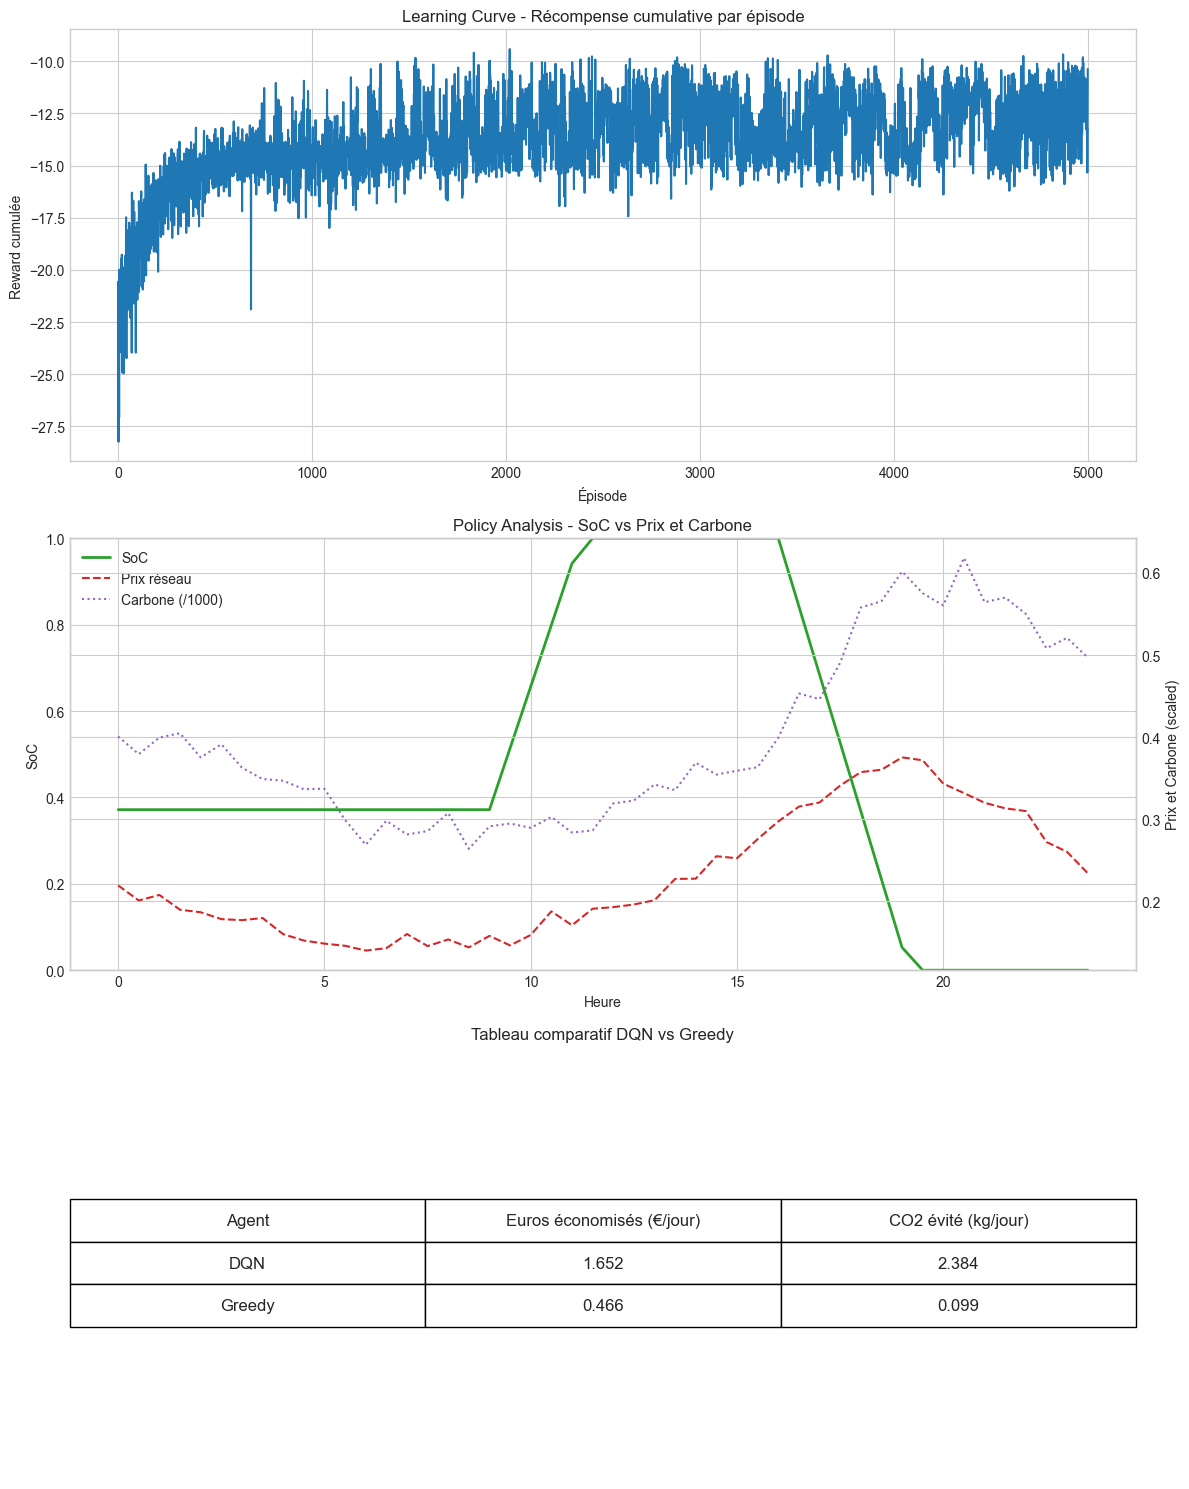

In [6]:
env_params = dict(
    alpha=1.0,
    beta=0.6,
    gamma=0.05,
    battery_capacity_kwh=10.0,
    max_power_kw=3.0,
    eta_charge=0.95,
    eta_discharge=0.95,
)

EPISODES = 5000  # mettre 100 pour debug rapide

train_env = SmartGridEnv(**env_params, seed=SEED)
dqn_agent, reward_history = train_dqn(train_env, episodes=EPISODES, seed=SEED)

rollout_env = SmartGridEnv(**env_params, seed=2026)
policy_rollout = run_episode_with_agent(
    rollout_env,
    policy_fn=lambda obs: dqn_agent.select_action(obs, greedy=True),
)

dqn_metrics, greedy_metrics = evaluate_agents(env_params, dqn_agent, n_eval_episodes=60)

print('===== Résultats moyens (évaluation) =====')
print(f"DQN    | Euros économisés: {dqn_metrics['euros_saved']:.3f} €/jour | CO2 évité: {dqn_metrics['co2_avoided']:.3f} kg/jour")
print(f"Greedy | Euros économisés: {greedy_metrics['euros_saved']:.3f} €/jour | CO2 évité: {greedy_metrics['co2_avoided']:.3f} kg/jour")

plot_results(reward_history, policy_rollout, dqn_metrics, greedy_metrics)

## Lecture rapide des résultats
- **Learning curve**: plus la reward cumulée augmente (moins négative), mieux l'agent apprend.
- **Policy analysis**: le SoC devrait monter sur plages de prix/carbone favorables et baisser sur pics coûteux/carbonés.
- **Tableau comparatif**: comparer directement l'impact économique et environnemental de DQN vs Greedy.